# Outbreak Response Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('fact_outbreak.csv')
df.head()

,outbreak_id,date_id,state_id,disease_id,source_id,new_outbreak_flag,controlled_flag,containment_rate_pct,response_time_hours,alert_level,predicted_cases,historical_cases,forecast_accuracy_pct,hospital_readiness_score,resource_readiness_score,emergency_alert_flag,state_name_raw
0,1,6,3,6,6,True,True,100.0,55.2,High,42,44,97.8,62.4,71.6,False,Assam
1,2,28,32,4,3,True,True,93.5,38.9,Moderate,2772,3768,74.5,99.0,75.9,False,Puducherry
2,3,8,20,3,4,True,True,100.0,80.9,Moderate,4406,3434,71.4,67.1,62.8,False,Punjab
3,4,23,2,12,4,True,True,82.9,49.0,Moderate,3024,3885,80.7,70.1,55.7,False,Arunachal Pradesh
4,5,7,32,8,5,True,True,100.0,73.2,High,1232,1013,75.1,51.0,71.6,False,Puducherry


## 1. How many outbreaks occurred, and what was the average response time?

In [3]:
total_outbreaks = len(df)
avg_response = df['response_time_hours'].mean()

print(f"Total number of outbreaks: {total_outbreaks}")
print(f"Average response time: {avg_response:.2f} hours")

Total number of outbreaks: 2530
Average response time: 52.47 hours


## 2. How effective were containment measures

In [4]:
avg_containment = df['containment_rate_pct'].mean()
controlled_pct = (df['controlled_flag'] == True).mean() * 100

print(f"Average containment rate: {avg_containment:.2f}%")
print(f"Percentage of outbreaks successfully controlled: {controlled_pct:.2f}%")

Average containment rate: 64.50%
Percentage of outbreaks successfully controlled: 71.11%


## 3. Which states responded fastest and which were slowest?

In [5]:
state_response = df.groupby('state_name_raw')['response_time_hours'].mean().sort_values()

print("Top 5 FASTEST responding states (Avg hours):")
print(state_response.head())
print("\nTop 5 SLOWEST responding states (Avg hours):")
print(state_response.tail())

Top 5 FASTEST responding states (Avg hours):
state_name_raw
himachal pradesh     4.1
GOA                  6.6
PUNJAB              10.3
ASSAM               16.1
west bengal         18.1
Name: response_time_hours, dtype: float64

Top 5 SLOWEST responding states (Avg hours):
state_name_raw
assam               86.5
uttarakhand         88.5
HIMACHAL PRADESH    95.4
delhi (nct)         95.7
RAJASTHAN            NaN
Name: response_time_hours, dtype: float64


## 4. Visualizations (Bar Chart & Line Chart)

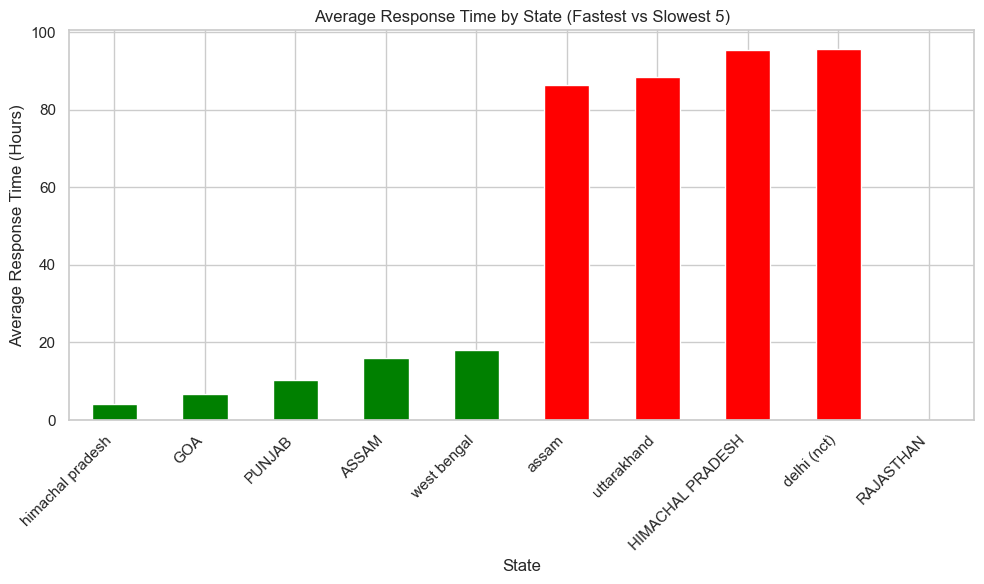

In [6]:
# Bar Chart: Fastest and Slowest States
fig, ax = plt.subplots(figsize=(10, 6))

# Combine top 5 and bottom 5 for the chart
extremes = pd.concat([state_response.head(), state_response.tail()])
colors = ['green']*5 + ['red']*5

extremes.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Average Response Time by State (Fastest vs Slowest 5)')
ax.set_ylabel('Average Response Time (Hours)')
ax.set_xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

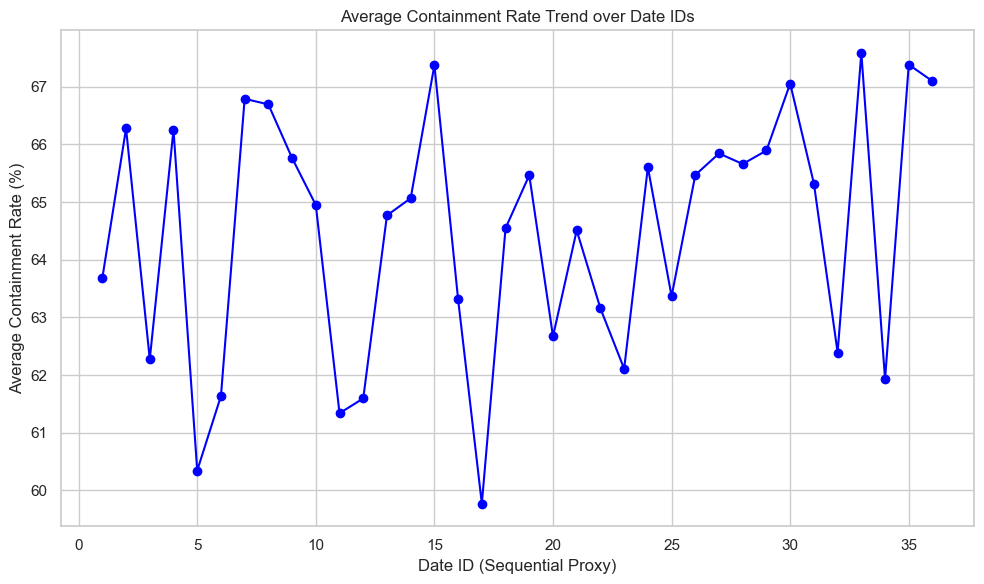

In [7]:
# Line Chart: Containment Rate over Time (using date_id as a proxy for time)
# We group by date_id to see the trend of containment rate
time_trend = df.groupby('date_id')['containment_rate_pct'].mean().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(time_trend.index, time_trend.values, marker='o', linestyle='-', color='blue')
plt.title('Average Containment Rate Trend over Date IDs')
plt.xlabel('Date ID (Sequential Proxy)')
plt.ylabel('Average Containment Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Exploring correlations

### 5.1 Correlation Heatmap
Let's see how different numerical variables (like predicted cases vs historical cases, or readiness scores) correlate with each other.

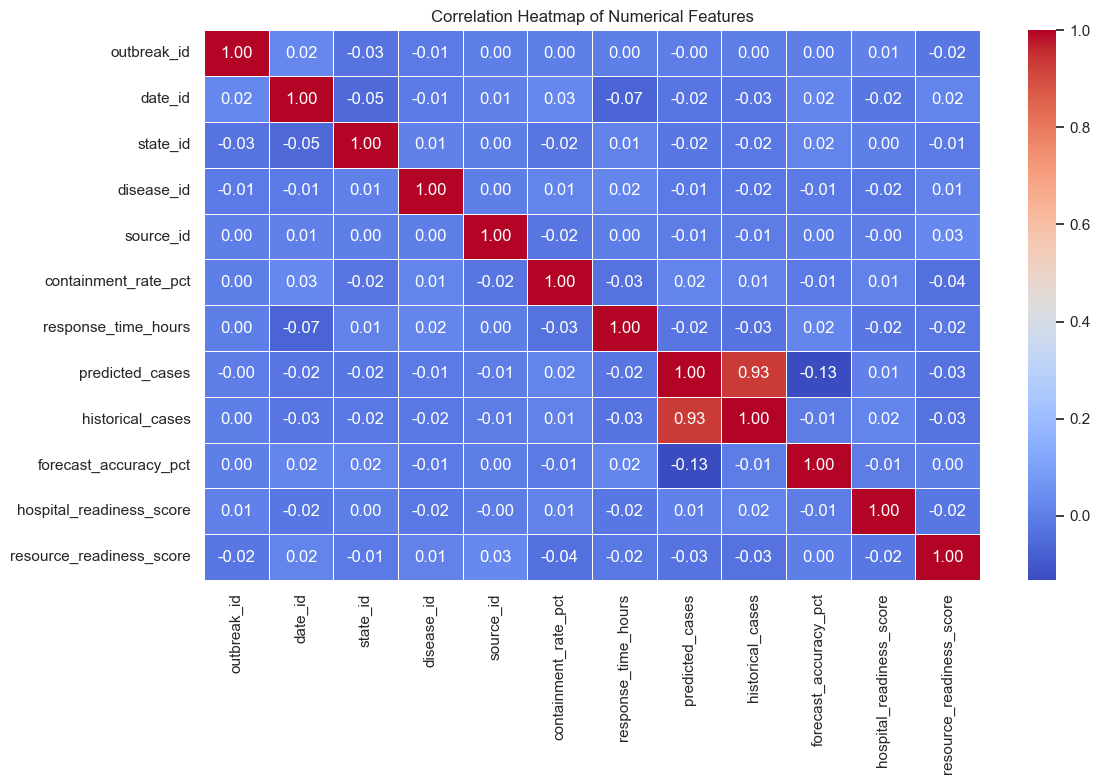

In [8]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### 5.4 Distribution of Cases and Readiness Scores

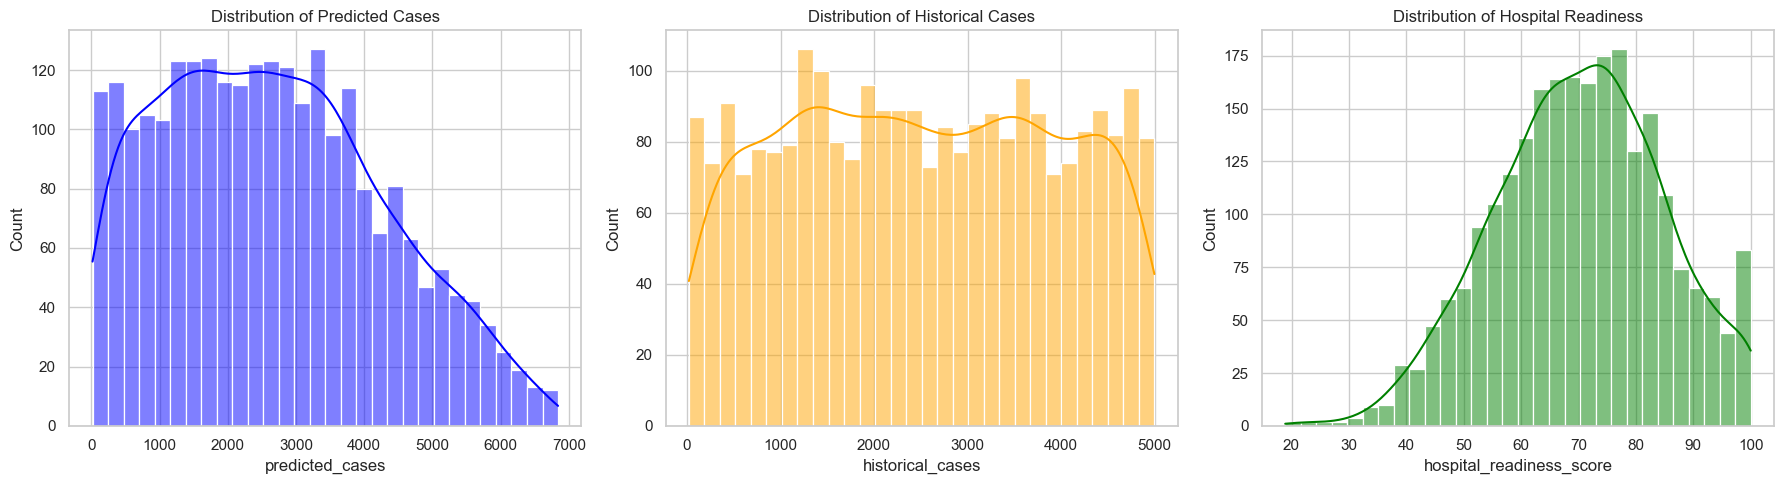

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['predicted_cases'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Predicted Cases')

sns.histplot(df['historical_cases'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Historical Cases')

sns.histplot(df['hospital_readiness_score'], bins=30, kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Hospital Readiness')

plt.tight_layout()
plt.show()

 ## 6. Relationships between different categorical and numerical variables.

### 6.1 Predicted vs Historical Cases
A scatter plot to observe how well the predicted cases align with historical case numbers.

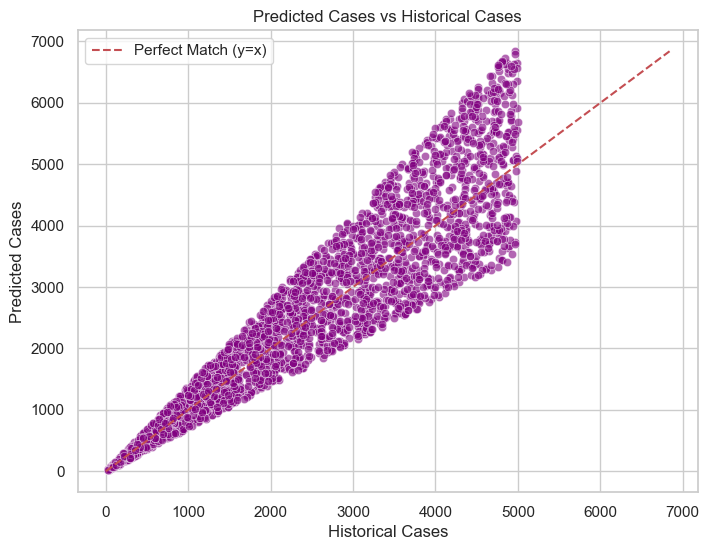

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='historical_cases', y='predicted_cases', alpha=0.6, color='purple')
# Adding a reference line y=x
max_val = max(df['historical_cases'].max(), df['predicted_cases'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Match (y=x)')
plt.title('Predicted Cases vs Historical Cases')
plt.xlabel('Historical Cases')
plt.ylabel('Predicted Cases')
plt.legend()
plt.show()

### 6.2 Containment Rate by Alert Level
A box plot to see the spread of containment rates across different alert levels.

C:\Users\mouni\AppData\Local\Temp\ipykernel_1380\2775464390.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='alert_level', y='containment_rate_pct', palette='Set2')


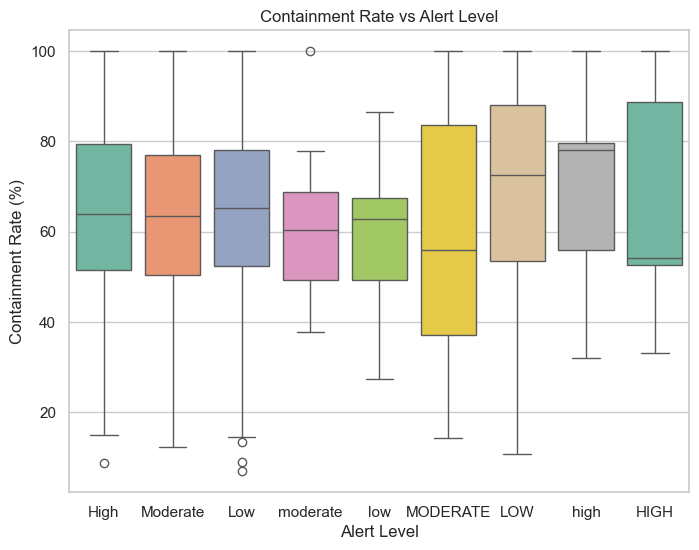

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='alert_level', y='containment_rate_pct', palette='Set2')
plt.title('Containment Rate vs Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Containment Rate (%)')
plt.show()

### 6.3 Response Time by Outbreak Control Status
Does a faster response time correlate with outbreaks being controlled?

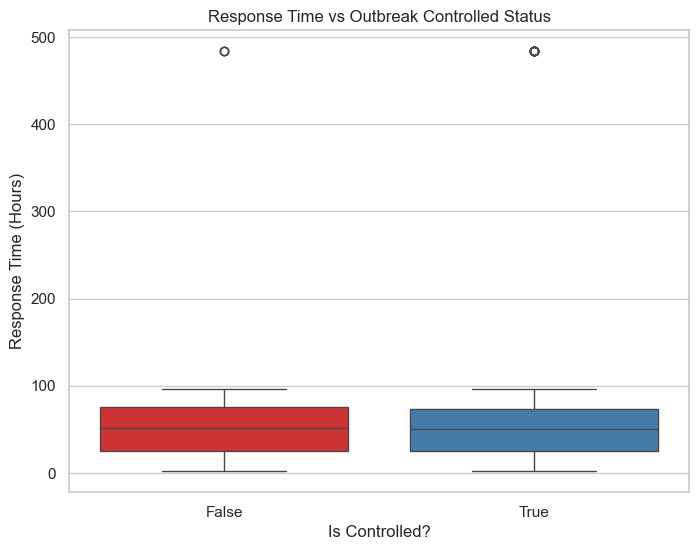

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='controlled_flag', y='response_time_hours', hue='controlled_flag', legend=False, palette='Set1')
plt.title('Response Time vs Outbreak Controlled Status')
plt.xlabel('Is Controlled?')
plt.ylabel('Response Time (Hours)')
plt.show()

### 6.4 Number of Outbreaks by Alert Level

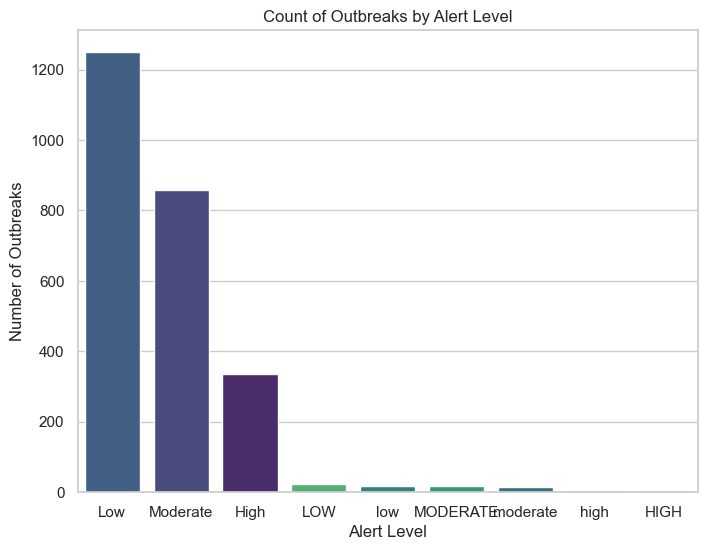

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='alert_level', hue='alert_level', legend=False, palette='viridis', order=df['alert_level'].value_counts().index)
plt.title('Count of Outbreaks by Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Number of Outbreaks')
plt.show()